# 04 — Patterns temporels et signal de demande
Objectif : mesurer l'effet des variables calendaires sur les prix et auditer la fiabilité de `sur_demande` comme proxy de la demande.

**Source :** PostgreSQL `hotel_features` (agrégations SQL).

> ⚠️ **Risque ouvert (ml/CLAUDE.md)** : la sémantique exacte de `sur_demande` n'a pas encore été auditée rigoureusement. Ce notebook constitue cet audit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import sys
sys.path.insert(0, "..")
from feature_engineering.config import POSTGRES_URI

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"savefig.dpi": 300, "figure.dpi": 120})
MOIS = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
JOURS = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]

engine = create_engine(POSTGRES_URI)

FIGURES_DIR = Path("figures/04_temporal_demand")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    path = FIGURES_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"Enregistré → {path}")

## 1. Patterns mensuels et saisonniers

Enregistré → figures\04_temporal_demand\01_patterns_mensuels.png


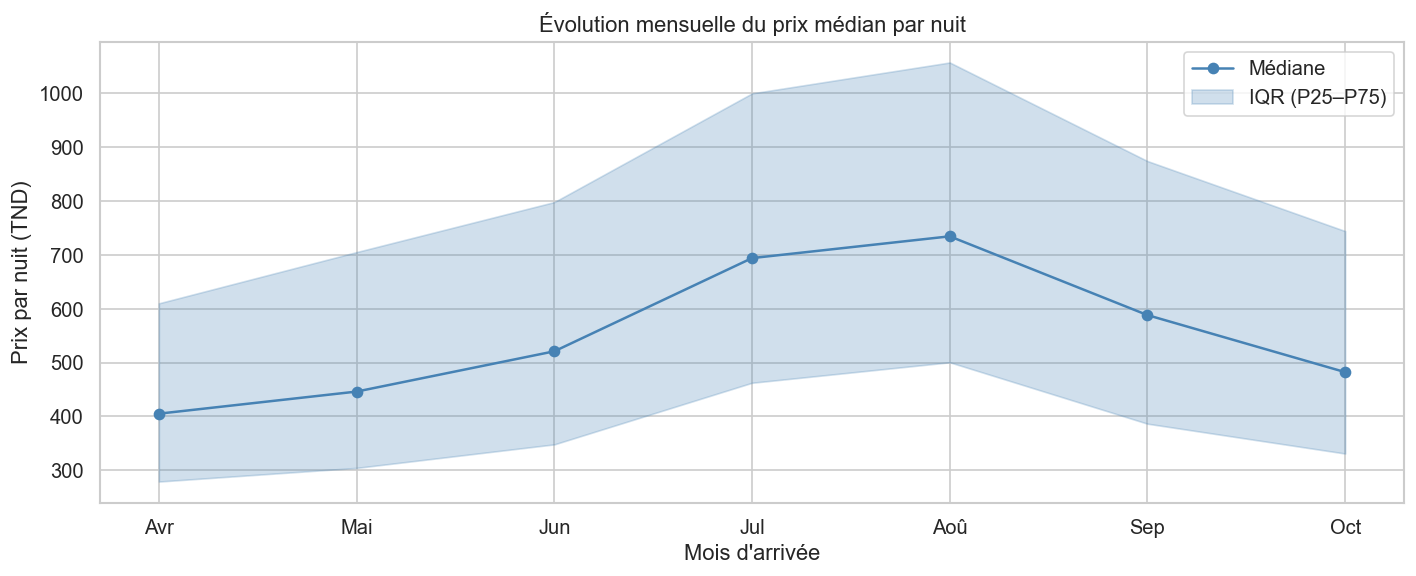

,check_in_month,p25,mediane,p75,n,mois_label
0,4,279.000000,405.000000,609.900024,921728,Avr
1,5,304.350006,446.040009,705.000000,6063635,Mai
2,6,348.000000,520.799988,797.849976,5210180,Jun
3,7,462.369995,693.840027,999.599976,2059614,Jul
4,8,500.399994,734.250000,1057.000000,2029469,Aoû
5,9,386.399994,588.000000,874.000000,2033573,Sep
6,10,331.000000,482.119995,744.000000,1558638,Oct


In [2]:
monthly_q = pd.read_sql("""
    SELECT check_in_month,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_per_night) AS p25,
           PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_per_night) AS p75,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY check_in_month
    ORDER BY check_in_month
""", engine)

monthly_q["mois_label"] = monthly_q["check_in_month"].apply(lambda m: MOIS[m-1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_q["mois_label"], monthly_q["mediane"], color="steelblue", marker="o", label="Médiane")
ax.fill_between(monthly_q["mois_label"], monthly_q["p25"], monthly_q["p75"],
                alpha=0.25, color="steelblue", label="IQR (P25–P75)")
ax.set_xlabel("Mois d'arrivée")
ax.set_ylabel("Prix par nuit (TND)")
ax.set_title("Évolution mensuelle du prix médian par nuit")
ax.legend()
plt.tight_layout()
save_fig("01_patterns_mensuels")
plt.show()

monthly_q

Enregistré → figures\04_temporal_demand\01b_patterns_trimestriels.png


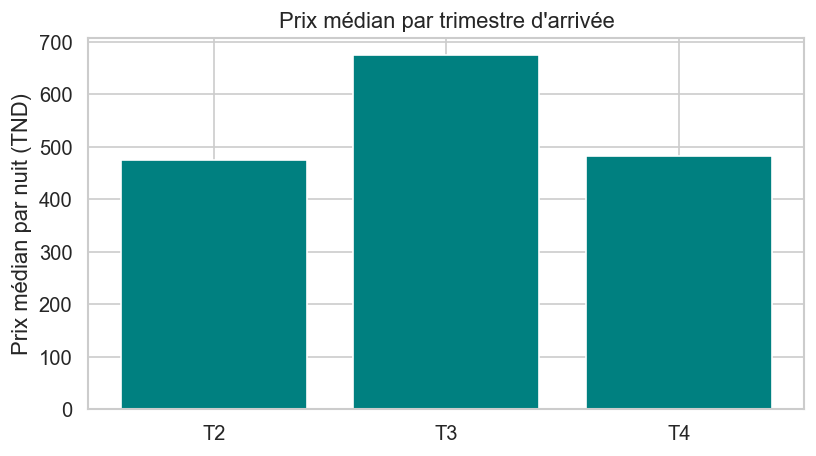

In [3]:
quarter_q = pd.read_sql("""
    SELECT check_in_quarter,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY check_in_quarter
    ORDER BY check_in_quarter
""", engine)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"T{q}" for q in quarter_q["check_in_quarter"]], quarter_q["mediane"], color="teal")
ax.set_ylabel("Prix médian par nuit (TND)")
ax.set_title("Prix médian par trimestre d'arrivée")
plt.tight_layout()
save_fig("01b_patterns_trimestriels")
plt.show()

## 2. Effet Ramadan

Enregistré → figures\04_temporal_demand\02_effet_ramadan.png


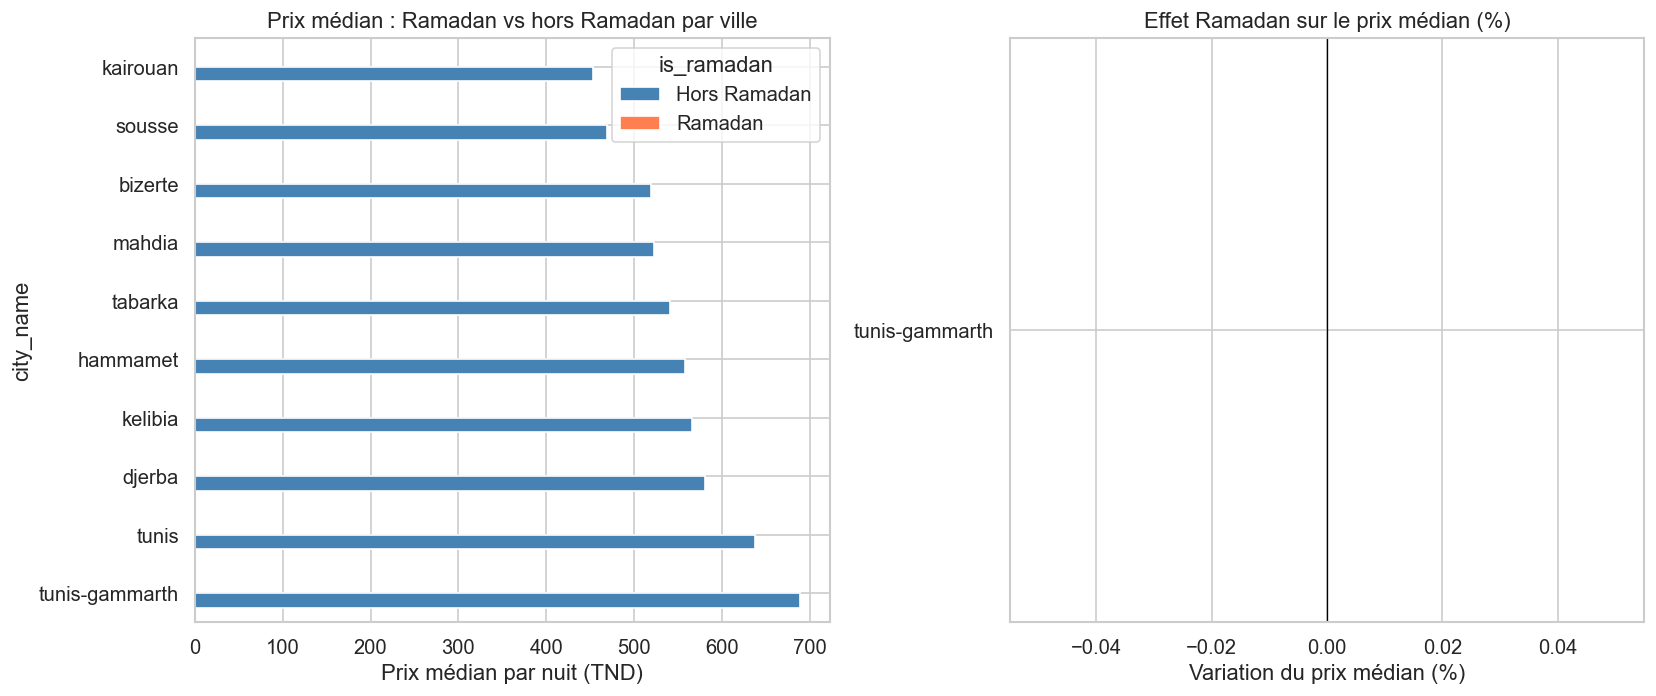

is_ramadan,Hors Ramadan,Ramadan,effet_pct
city_name,,,
tunis-gammarth,688.429993,NaN,NaN
tunis,638.090027,NaN,NaN
djerba,580.369995,NaN,NaN
kelibia,565.599976,NaN,NaN
hammamet,557.549988,NaN,NaN
tabarka,541.090027,NaN,NaN
mahdia,522.859985,NaN,NaN
bizerte,519.200012,NaN,NaN
sousse,469.000000,NaN,NaN


In [4]:
ramadan_q = pd.read_sql("""
    SELECT is_ramadan, city_name,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY is_ramadan, city_name
    HAVING COUNT(*) >= 200
    ORDER BY city_name, is_ramadan
""", engine)

pivot_ram = ramadan_q.pivot(index="city_name", columns="is_ramadan", values="mediane").dropna()
# Rename safely regardless of bool/int encoding from Postgres
pivot_ram = pivot_ram.rename(columns={False: "Hors Ramadan", True: "Ramadan",
                                       0: "Hors Ramadan", 1: "Ramadan"})
for _col in ["Hors Ramadan", "Ramadan"]:
    if _col not in pivot_ram.columns:
        pivot_ram[_col] = float("nan")
pivot_ram = pivot_ram[["Hors Ramadan", "Ramadan"]]

# Top 10 cities by max price
pivot_ram = pivot_ram.nlargest(10, "Hors Ramadan")
pivot_ram["effet_pct"] = (pivot_ram["Ramadan"] - pivot_ram["Hors Ramadan"]) / pivot_ram["Hors Ramadan"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pivot_ram[["Hors Ramadan", "Ramadan"]].plot(kind="barh", ax=axes[0],
                                              color=["steelblue", "coral"])
axes[0].set_xlabel("Prix médian par nuit (TND)")
axes[0].set_title("Prix médian : Ramadan vs hors Ramadan par ville")

colors = ["green" if v >= 0 else "crimson" for v in pivot_ram["effet_pct"]]
axes[1].barh(pivot_ram.index, pivot_ram["effet_pct"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Variation du prix médian (%)")
axes[1].set_title("Effet Ramadan sur le prix médian (%)")

plt.tight_layout()
save_fig("02_effet_ramadan")
plt.show()
pivot_ram

## 3. Corrélation avec les vacances scolaires européennes

Enregistré → figures\04_temporal_demand\03_vacances_europeennes.png


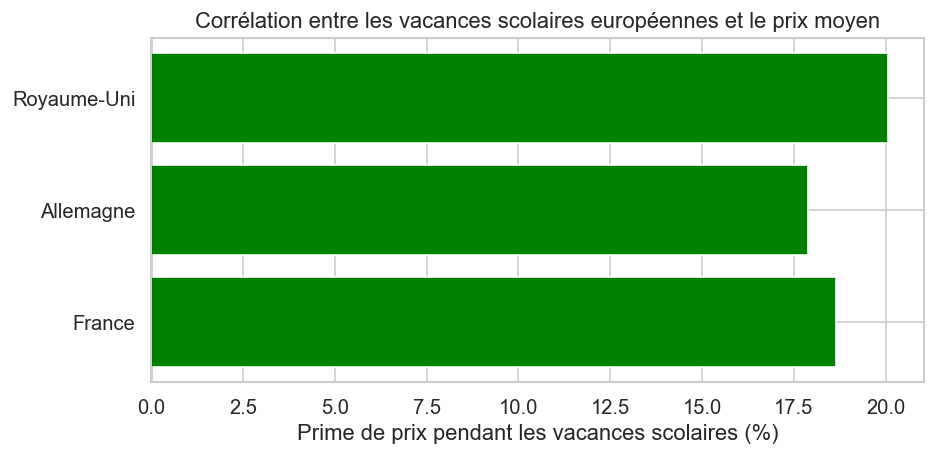

,Pays,Prix pendant vacances,Prix hors vacances,Effet (%)
0,France,757.179575,638.116198,18.658573
1,Allemagne,730.014550,619.283701,17.880472
2,Royaume-Uni,770.883624,642.124991,20.051958


In [5]:
eu_results = []
for pays, col in [("France", "is_school_holiday_france"),
                  ("Allemagne", "is_school_holiday_germany"),
                  ("Royaume-Uni", "is_school_holiday_uk")]:
    row = pd.read_sql(f"""
        SELECT
            AVG(CASE WHEN {col} THEN price_per_night END) AS prix_vacances,
            AVG(CASE WHEN NOT {col} THEN price_per_night END) AS prix_hors_vacances,
            COUNT(*) AS n
        FROM hotel_features
    """, engine).iloc[0]
    effet = (row["prix_vacances"] - row["prix_hors_vacances"]) / row["prix_hors_vacances"] * 100
    eu_results.append({"Pays": pays, "Prix pendant vacances": row["prix_vacances"],
                       "Prix hors vacances": row["prix_hors_vacances"],
                       "Effet (%)": effet})

eu_df = pd.DataFrame(eu_results)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["green" if v >= 0 else "crimson" for v in eu_df["Effet (%)"]]
ax.barh(eu_df["Pays"], eu_df["Effet (%)"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Prime de prix pendant les vacances scolaires (%)")
ax.set_title("Corrélation entre les vacances scolaires européennes et le prix moyen")
plt.tight_layout()
save_fig("03_vacances_europeennes")
plt.show()
eu_df

## 4. Patterns jour de la semaine (au-delà du flag weekend)

Enregistré → figures\04_temporal_demand\04_patterns_jour_semaine.png


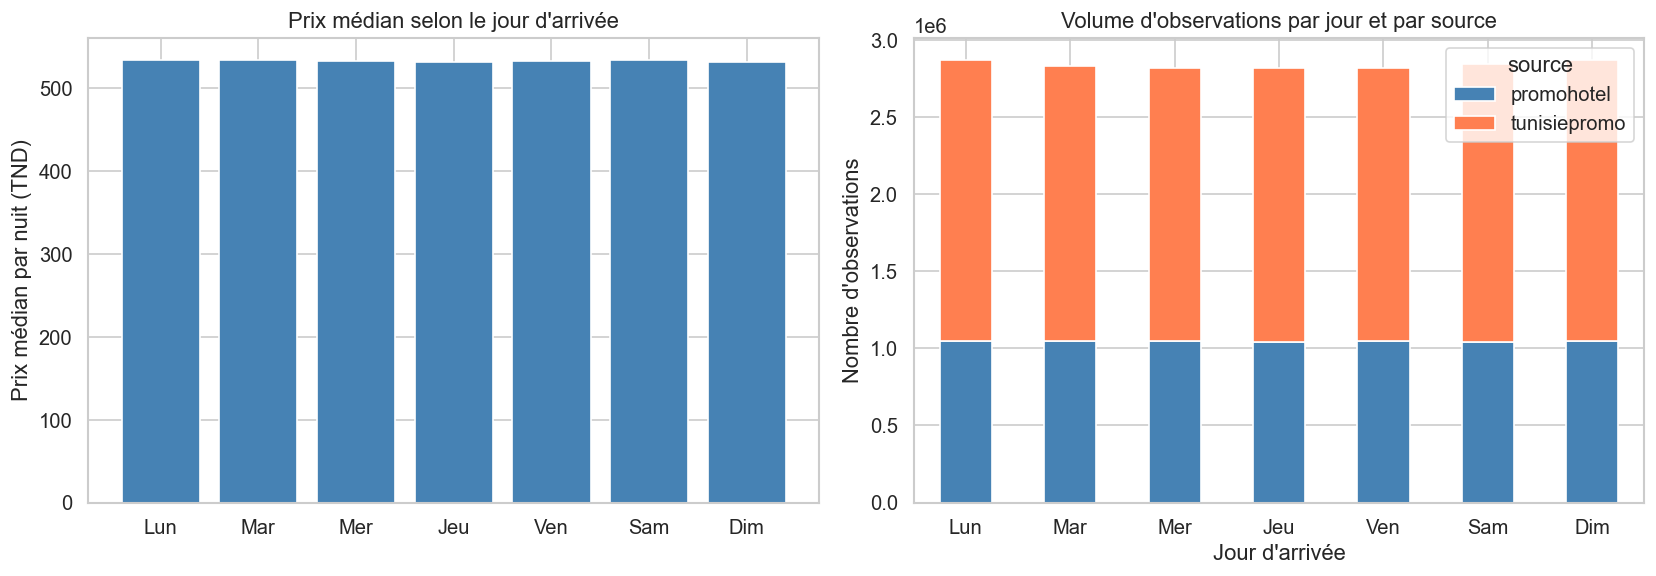

In [6]:
dow_q = pd.read_sql("""
    SELECT check_in_dow,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY check_in_dow
    ORDER BY check_in_dow
""", engine)

dow_source_q = pd.read_sql("""
    SELECT check_in_dow, source, COUNT(*) AS n
    FROM hotel_features
    GROUP BY check_in_dow, source
    ORDER BY check_in_dow, source
""", engine)

dow_q["jour"] = dow_q["check_in_dow"].apply(lambda d: JOURS[d])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_q["jour"], dow_q["mediane"], color="steelblue")
axes[0].set_ylabel("Prix médian par nuit (TND)")
axes[0].set_title("Prix médian selon le jour d'arrivée")

pivot_dow = dow_source_q.pivot(index="check_in_dow", columns="source", values="n").fillna(0)
pivot_dow.index = [JOURS[i] for i in pivot_dow.index]
pivot_dow.plot(kind="bar", stacked=True, ax=axes[1], color=["steelblue", "coral"])
axes[1].set_xlabel("Jour d'arrivée")
axes[1].set_ylabel("Nombre d'observations")
axes[1].set_title("Volume d'observations par jour et par source")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
save_fig("04_patterns_jour_semaine")
plt.show()

## 5. Audit sémantique de `sur_demande`

> **Question ouverte :** que signifie `sur_demande = True` dans les données brutes ? Prix indicatif ? Chambre non disponible à prix fixe ? La réponse détermine si la feature `sur_demande_rate_*` est un proxy de tension du marché ou du bruit.

Enregistré → figures\04_temporal_demand\05a_taux_global_sur_demande.png


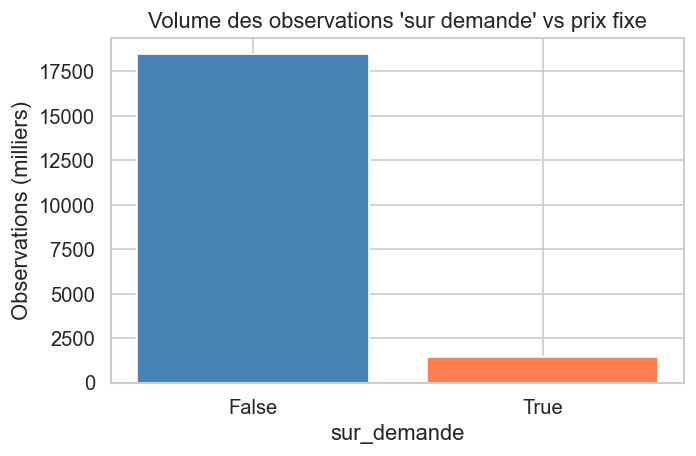

sur_demande=False : 18,469,725 (92.9%)
sur_demande=True : 1,407,112 (7.1%)


In [7]:
# 5a — Taux global
sd_global = pd.read_sql("""
    SELECT sur_demande, COUNT(*) AS n
    FROM hotel_features
    GROUP BY sur_demande
""", engine)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sd_global["sur_demande"].astype(str), sd_global["n"] / 1000,
       color=["steelblue", "coral"])
ax.set_xlabel("sur_demande")
ax.set_ylabel("Observations (milliers)")
ax.set_title("Volume des observations 'sur demande' vs prix fixe")
plt.tight_layout()
save_fig("05a_taux_global_sur_demande")
plt.show()

total = sd_global["n"].sum()
for _, row in sd_global.iterrows():
    print(f"sur_demande={row['sur_demande']} : {row['n']:,} ({row['n']/total*100:.1f}%)")

Enregistré → figures\04_temporal_demand\05b_sur_demande_par_fenetre.png


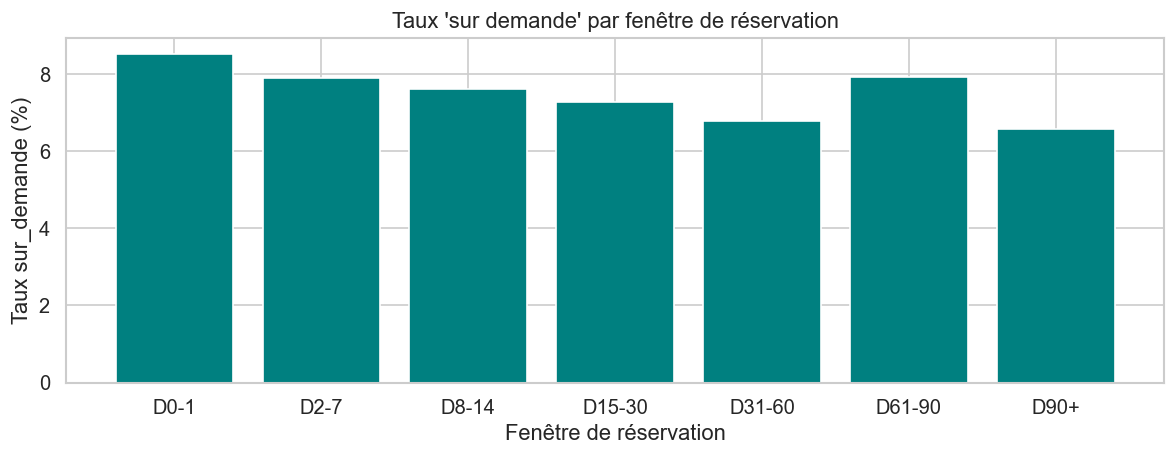

In [8]:
# 5b — Taux par fenêtre de réservation
BUCKET_ORDER = ["D0-1", "D2-7", "D8-14", "D15-30", "D31-60", "D61-90", "D90+"]

sd_window_q = pd.read_sql("""
    SELECT
        CASE
            WHEN days_until_checkin BETWEEN 0 AND 1   THEN 'D0-1'
            WHEN days_until_checkin BETWEEN 2 AND 7   THEN 'D2-7'
            WHEN days_until_checkin BETWEEN 8 AND 14  THEN 'D8-14'
            WHEN days_until_checkin BETWEEN 15 AND 30 THEN 'D15-30'
            WHEN days_until_checkin BETWEEN 31 AND 60 THEN 'D31-60'
            WHEN days_until_checkin BETWEEN 61 AND 90 THEN 'D61-90'
            ELSE 'D90+'
        END AS fenetre,
        AVG(CASE WHEN sur_demande THEN 1.0 ELSE 0.0 END) AS taux_sur_demande,
        COUNT(*) AS n
    FROM hotel_features
    GROUP BY fenetre
""", engine)

sd_window_q["fenetre"] = pd.Categorical(sd_window_q["fenetre"], categories=BUCKET_ORDER, ordered=True)
sd_window_q = sd_window_q.sort_values("fenetre")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sd_window_q["fenetre"].astype(str), sd_window_q["taux_sur_demande"] * 100,
       color="teal")
ax.set_xlabel("Fenêtre de réservation")
ax.set_ylabel("Taux sur_demande (%)")
ax.set_title("Taux 'sur demande' par fenêtre de réservation")
plt.tight_layout()
save_fig("05b_sur_demande_par_fenetre")
plt.show()

Enregistré → figures\04_temporal_demand\05c_prix_sur_demande.png


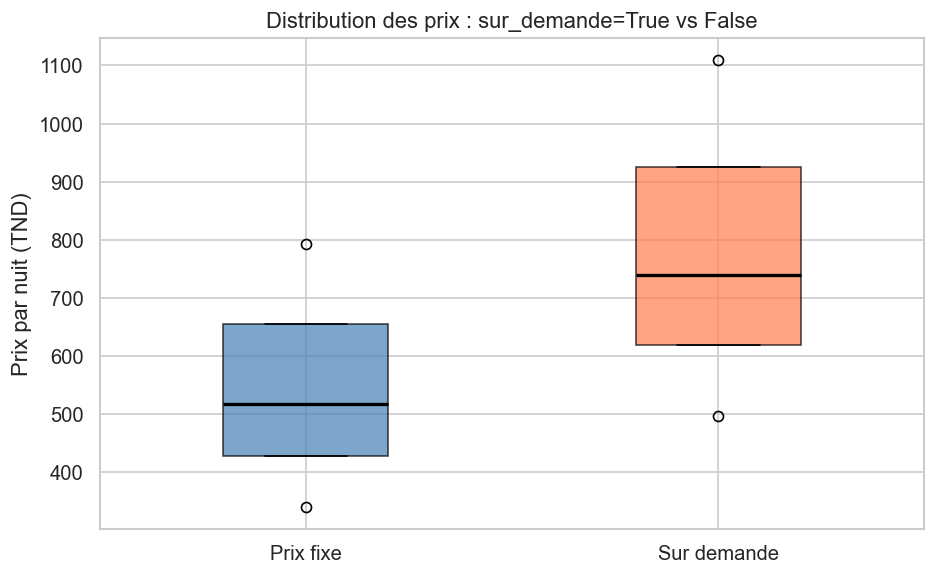

,sur_demande,p10,p25,mediane,p75,p90
0,False,236.559998,340.200012,516.599976,792.000000,1150.000000
1,True,322.000000,496.000000,740.000000,1109.533325,1523.199951


In [9]:
# 5c — Prix sur_demande=True vs False
sd_price_q = pd.read_sql("""
    SELECT sur_demande,
           PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY price_per_night) AS p10,
           PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY price_per_night) AS p25,
           PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY price_per_night) AS mediane,
           PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY price_per_night) AS p75,
           PERCENTILE_CONT(0.9)  WITHIN GROUP (ORDER BY price_per_night) AS p90
    FROM hotel_features
    GROUP BY sur_demande
""", engine)

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Prix fixe", "Sur demande"]
for i, (_, row) in enumerate(sd_price_q.iterrows()):
    ax.boxplot(
        [row["p25"], row["mediane"], row["p75"]],
        positions=[i],
        widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor=["steelblue", "coral"][i], alpha=0.7),
        medianprops=dict(color="black", linewidth=2),
        whis=0,
    )
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel("Prix par nuit (TND)")
ax.set_title("Distribution des prix : sur_demande=True vs False")
plt.tight_layout()
save_fig("05c_prix_sur_demande")
plt.show()
sd_price_q

Enregistré → figures\04_temporal_demand\05d_taux_hotel_sur_demande.png


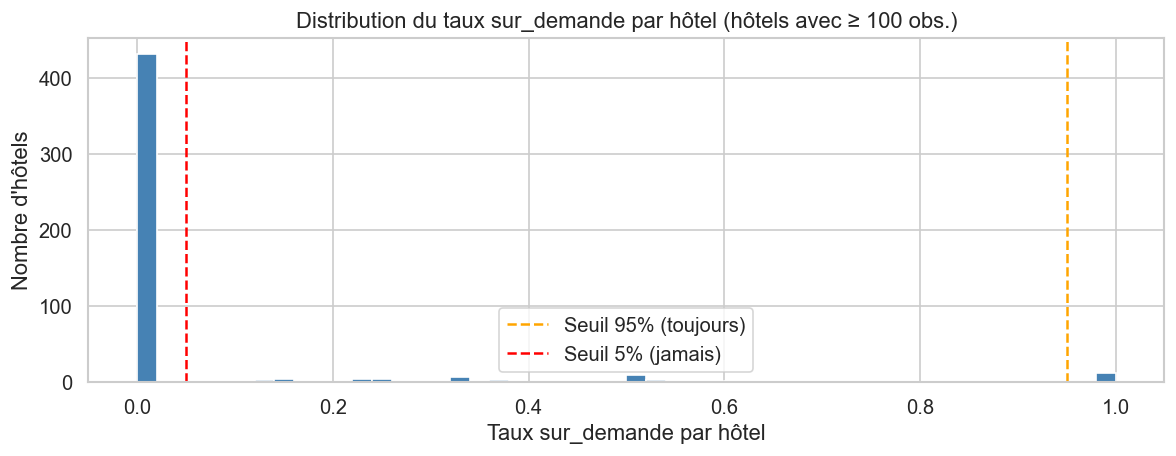

Hôtels toujours sur_demande (taux > 95%) : 12
Hôtels jamais sur_demande  (taux < 5%)  : 434


In [10]:
# 5d — Hôtels toujours / jamais sur_demande
hotel_sd_q = pd.read_sql("""
    SELECT hotel_name_normalized,
           AVG(CASE WHEN sur_demande THEN 1.0 ELSE 0.0 END) AS taux,
           COUNT(*) AS n
    FROM hotel_features
    GROUP BY hotel_name_normalized
    HAVING COUNT(*) >= 100
    ORDER BY taux DESC
""", engine)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hotel_sd_q["taux"], bins=50, color="steelblue", edgecolor="white")
ax.axvline(0.95, color="orange", linestyle="--", label="Seuil 95% (toujours)")
ax.axvline(0.05, color="red", linestyle="--", label="Seuil 5% (jamais)")
ax.set_xlabel("Taux sur_demande par hôtel")
ax.set_ylabel("Nombre d'hôtels")
ax.set_title("Distribution du taux sur_demande par hôtel (hôtels avec ≥ 100 obs.)")
ax.legend()
plt.tight_layout()
save_fig("05d_taux_hotel_sur_demande")
plt.show()

always = (hotel_sd_q["taux"] > 0.95).sum()
never  = (hotel_sd_q["taux"] < 0.05).sum()
print(f"Hôtels toujours sur_demande (taux > 95%) : {always}")
print(f"Hôtels jamais sur_demande  (taux < 5%)  : {never}")

Enregistré → figures\04_temporal_demand\05e_sur_demande_vs_prix.png


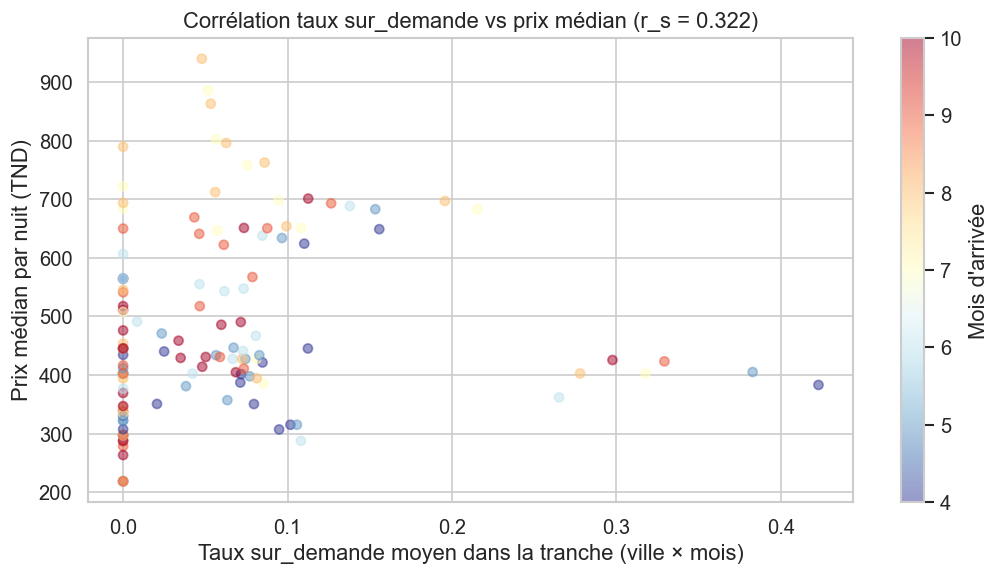

Corrélation de Spearman : r = 0.322


In [11]:
# 5e — Corrélation taux sur_demande vs prix médian dans la tranche (ville × mois)
sd_corr_q = pd.read_sql("""
    SELECT city_name, check_in_month,
           AVG(sur_demande_rate_city_checkin) AS taux_rate,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY price_per_night) AS prix_mediane
    FROM hotel_features
    GROUP BY city_name, check_in_month
    HAVING COUNT(*) >= 100
""", engine)

# Spearman via pandas — no scipy required
paired = sd_corr_q[["taux_rate", "prix_mediane"]].dropna()
r = paired.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(sd_corr_q["taux_rate"], sd_corr_q["prix_mediane"],
                alpha=0.5, c=sd_corr_q["check_in_month"], cmap="RdYlBu_r", s=30)
plt.colorbar(sc, ax=ax, label="Mois d'arrivée")
ax.set_xlabel("Taux sur_demande moyen dans la tranche (ville × mois)")
ax.set_ylabel("Prix médian par nuit (TND)")
ax.set_title(f"Corrélation taux sur_demande vs prix médian (r_s = {r:.3f})")
plt.tight_layout()
save_fig("05e_sur_demande_vs_prix")
plt.show()
print(f"Corrélation de Spearman : r = {r:.3f}")

## Conclusions pour la modélisation

- **Saisonnalité** : pic de prix en été (T3) ; creux hivernal. L'effet mensuel est marqué → `check_in_month` et `check_in_quarter` sont des features retenues.

- **Effet Ramadan** : la direction (hausse ou baisse) et la magnitude sont à renseigner après exécution. Pour le tourisme de loisirs en Tunisie, une baisse pendant le Ramadan est attendue.

- **Vacances scolaires européennes** : si l'effet est > 5%, les flags `is_school_holiday_france/germany/uk` sont retenus comme features. Sinon, seul `days_to_nearest_european_holiday` (continu) est conservé.

- **Jour de la semaine** : l'analyse par jour (au-delà du boolean weekend) peut révéler des préférences de départ (samedi dominant pour les séjours 7 nuits). Si l'effet sur le prix est faible, `check_in_dow` peut être écarté.

- **Audit `sur_demande`** :
  - Si `sur_demande=True` est associé à un prix *similaire ou plus élevé* → la feature encode une tension de marché réelle → **retenir** `sur_demande_rate_city_checkin`.
  - Si `sur_demande=True` est associé à un prix *plus faible ou nul* → c'est un placeholder ou une indisponibilité → **exclure ou traiter séparément**.
  - Les hôtels avec taux > 95% (toujours sur demande) sont des cas dégénérés : leur `sur_demande_rate` est non informatif pour les autres hôtels du slice.
  - **Décision finale** : à renseigner après observation des résultats de la section 5c.